In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

GFs shape: (2, 252, 3, 40000)


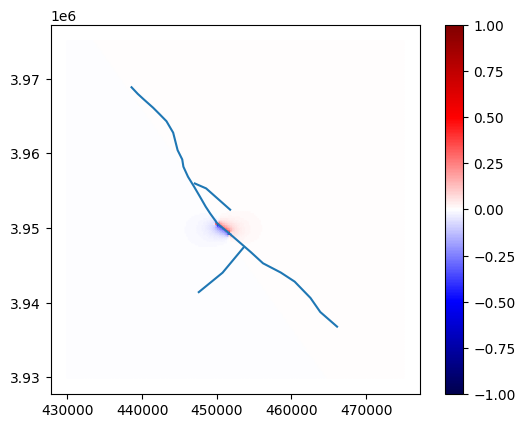

In [ ]:
from codes import Fault3d

filepath = "/Users/hintont/Dev/projects/ridgecrest/data/fault/fault_trace_utm.shp"
vertical_discretisation = [0, 500, 1500, 2500, 3500, 5000, 6500, 8500, 11500, 15000]
fault = Fault3d(trace_shp_filepath=filepath, vertical_discretisation=vertical_discretisation)

xs, ys = np.meshgrid(
    np.linspace(4.3e5, 4.75e5, 200),
    np.linspace(3.93e6, 3.975e6, 200)
)
xys = np.vstack((xs.flatten(), ys.flatten()))
fault = fault.compute_greens_functions(xys)

ax = fault.trace.plot()
sar = ax.scatter(xs, ys, c=fault.gfs[0,10,0,:], s=.3, zorder=.5, cmap="seismic", vmin=-1., vmax=1.)
plt.colorbar(sar)

Importing GRD: /Users/hintont/Dev/projects/Ridgecrest/data/insar/D071_20190704-0716/unwrapped.grd
  Loaded 6795141 pixels
  After bbox selection: 1372750 pixels
Computing spatial covariance...
  Sampling 5524 pixels from 1104870
  Sill=0.000289, Sigma=0.020253, Lambda=13168.6 m


(<Figure size 700x600 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

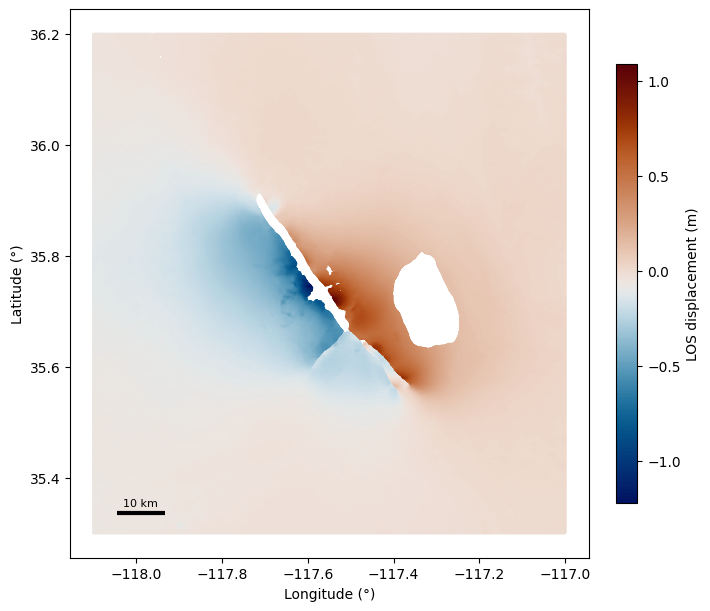

In [ ]:
from codes import InSAR
dir = "/Users/hintont/Dev/projects/Ridgecrest/data/insar/A064_20190704-0710/"
dir = "/Users/hintont/Dev/projects/Ridgecrest/data/insar/D071_20190704-0716/"

unw=dir+"unwrapped.grd"
e=dir+"east.grd"
n=dir+"north.grd"
u=dir+"up.grd"

bbox = (-118.1, -117.0 ,35.3, 36.2)
cov_mask_out = [ -117.88,-117.3,35.53,35.9]

insar = InSAR(unw_filepath=unw, los_filepaths=(e,n,u), utm_zone=11, bbox=bbox)
insar = insar.compute_covariance(mask_box=cov_mask_out, frac=0.005, distmax=25000)
insar = insar.downsample(fault, char_dist=-5000., expo_dist=1.1, min_size=500, start_size=16000, scaler=0.7, reject_distance=1000. )
insar = insar.build_Cd()
insar = insar.compute_greens_functions(fault)
insar.plot_covariance()
insar.plot()

Importing GNSS: /Users/hintont/Dev/projects/ridgecrest/data/gnss/unr_gps_offsets_full.txt
  Loaded 481 stations
  After distance filter (100.0 km): 48 stations
  Built diagonal Cd (96 x 96)
  Green's functions shape: (2, 252, 96)


(<Figure size 700x600 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

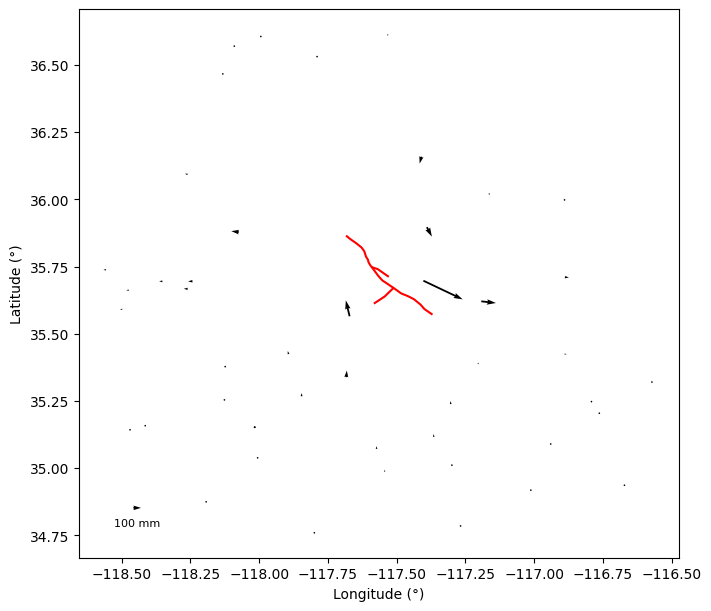

In [18]:
from codes import GNSS

gnss_path = "/Users/hintont/Dev/projects/ridgecrest/data/gnss/unr_gps_offsets_full.txt"
gnss = GNSS()
gnss = gnss.import_data(filepath=gnss_path, utm_zone=11, fault=fault, max_dist=100000)
gnss = gnss.compute_covariance(sde_scale_factor=30.)
gnss = gnss.compute_greens_functions(fault)
gnss.plot(fault=fault)

  'ascending-insar' (InSAR): 780 obs, G (780, 504), Cd (780, 780)
  'gnss' (GNSS): 96 obs, G (96, 504), Cd (96, 96)
  'ascending-insar': ramp added (cols slice(504, 507, None))
Assembled: 876 obs, 507 model params (252 SS + 252 DS patches + 3 ramp)
Saving data       -> /Users/hintont/Dev/projects/ridgecrest/data/inversion/data.h5
Saving covariance -> /Users/hintont/Dev/projects/ridgecrest/data/inversion/covariance.h5
Saving gf         -> /Users/hintont/Dev/projects/ridgecrest/data/inversion/gf.h5
  d (876,), Cd (876, 876), G (876, 507)
Running inversion...
  System: 876 obs x 507 params
  lsq_linear cost: 1.316273e+03, status: The first-order optimality measure is less than `tol`.
  'ascending-insar' residual RMS: 0.070107
  'gnss' residual RMS: 0.009842
InversionManager summary
  Total observations : 876
  Total model params : 507

  Dataset            Type           N obs  Row slice
  --------------------------------------------------
  ascending-insar    InSAR            780  0:780


/Users/hintont/Dev/codes/src/codes/InversionManager.py:363: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.872100035548967e-22.
  self.Cm    = scipy.linalg.inv(GtG)
/Users/hintont/Dev/codes/src/codes/InversionManager.py:365: RuntimeWarning: invalid value encountered in sqrt
  self.m_std = np.sqrt(np.diag(self.Cm))


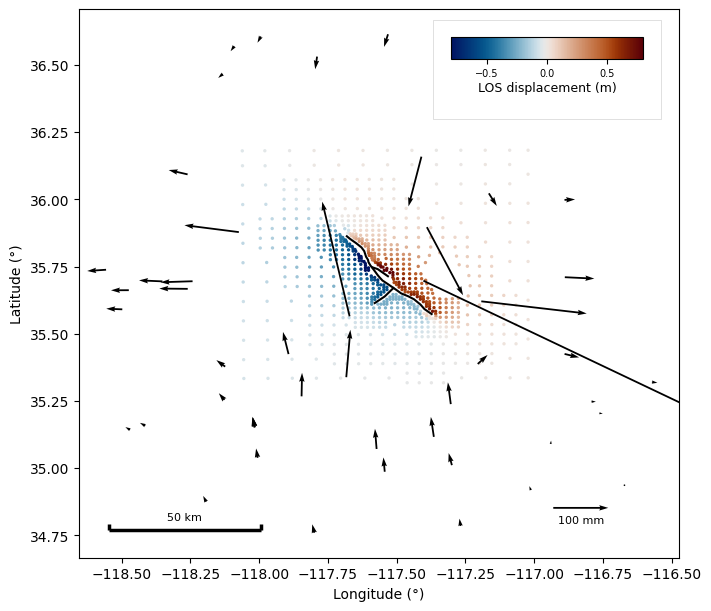

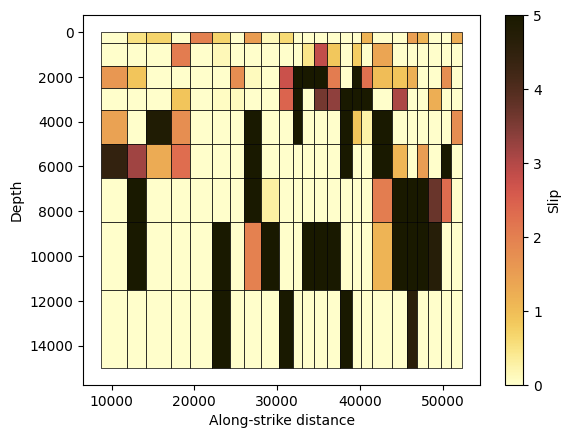

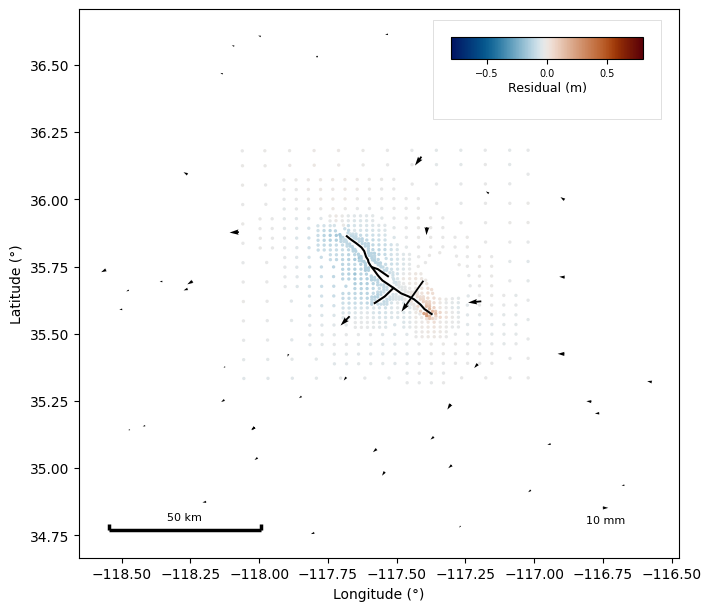

In [19]:
from codes import InversionManager

inversion = InversionManager()
inversion = inversion.set_datasets({"ascending-insar": insar, "gnss": gnss}, solve_for_ramp=["ascending-insar"]) # this should also assemble covariance matrix and greens function matrix
inversion.save_to_hdf5("/Users/hintont/Dev/projects/ridgecrest/data/inversion/") # save to h5 files in directory, under names "data", "covariance", and "gf"
# fault.save_patch_areas("/Users/hintont/Dev/projects/ridgecrest/data/inversion/patch_areas.h5")
inversion = inversion.run(bounds=(0., 8.)) # run a simple least squares inversion and store the result. Don't worry about plotting the result for now, can do that later.
inversion.summary()
inversion.plot_map(fault=fault, vlim=(-.8, .8), gnss_scale=.5)
fault.slips = np.array(inversion.m[:252])
ids = [i for i, (key, p) in enumerate(fault.patches.items()) if p.line_id==1]
fault.plot_slip(patch_indices=ids, vmin=0., vmax=5., cmap=cmc.lajolla_r)
inversion.plot_residuals(fault=fault, vlim=(-.8, .8), gnss_scale=.5)

import copy
altar_inversion = copy.deepcopy(inversion)

<HDF5 file "step_final.h5" (mode r)>
<HDF5 group "/ParameterSets" (3 members)>


<Axes: xlabel='Along-strike distance', ylabel='Depth'>

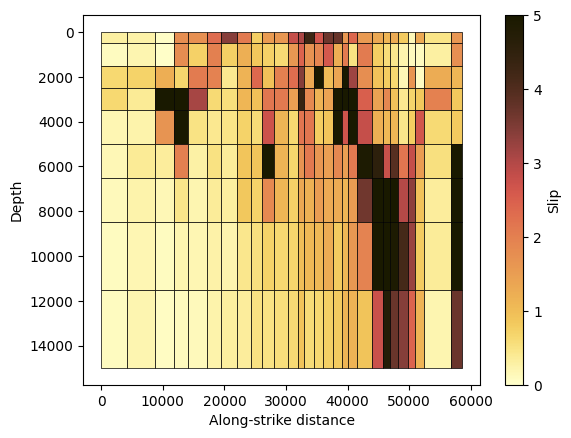

In [23]:
import h5py
import numpy as np
import copy
import cmcrameri.cm as cmc

altar_fault = copy.deepcopy(fault)

with h5py.File("/Users/hintont/Dev/projects/ridgecrest/results/inversion_results/in16/outputs/step_final.h5", "r") as f:
    print(f)
    print(f["ParameterSets"])
    strikeslips = f["ParameterSets"]["strikeslip"][:]

medians = np.median(strikeslips, axis=0)
sigmas = np.std(strikeslips, axis=0)

altar_fault.slips = medians
# altar_fault.sigmas = sigmas

altar_fault.plot_slip(vmin=0., vmax=5., cmap=cmc.lajolla_r)


    # with h5py.File(f"../results/inversion_results/{dirname}/outputs/{filename}", "r") as f:
    #     slips[i] = -soln(f["ParameterSets"]["strikeslipmain"], method="median")
    #     sigmas[i] = np.std(f["ParameterSets"]["strikeslipmain"], axis=0)

(array([41., 42., 44., 36., 28., 14., 10., 10., 10., 17.]),
 array([0.04193335, 0.29606669, 0.55020003, 0.80433337, 1.05846671,
        1.31260005, 1.5667334 , 1.82086674, 2.07500008, 2.32913342,
        2.58326676]),
 <BarContainer object of 10 artists>)

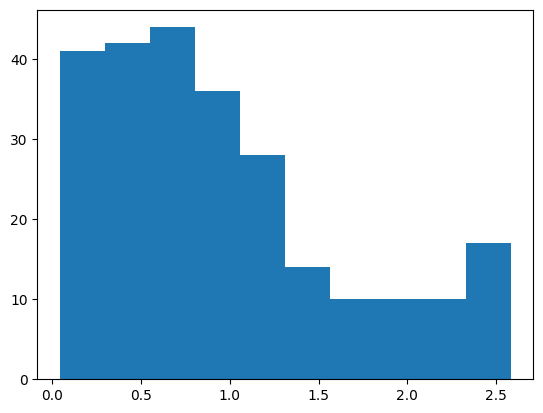

In [22]:
plt.hist(altar_fault.sigmas)

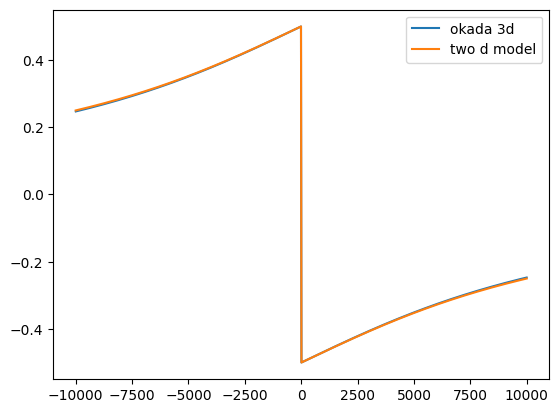

In [7]:
from codes import Fault3d, Patch
patch = Patch(-100000., 0., 10000., 100000., 0., 0.)
testfault = Fault3d()
testfault.patches = { (0,0): patch}
xs = np.zeros(1000)
ys = np.linspace(-10000., 10000., 1000)
pts = np.vstack((xs, ys))
testfault = testfault.compute_greens_functions(pts)

from codes import TwoDHomogeneousForwardModel
twodmodel = TwoDHomogeneousForwardModel()
twodmodel = twodmodel.run(ys)

plt.plot(ys, testfault.gfs[0,0,0,:], label="okada 3d")
plt.plot(ys, -twodmodel.sol, label="two d model")
plt.legend()